# SCADA Functionality Test Visualiser

**Author:** Erick Chauke

SCADA stands for Supervisory Control and Data Acquisition, the system that runs a power plant and logs its measurements every second. Each grid-code functionality test leaves one of these logger spreadsheets, and today every one is checked by eye against the acceptance procedure. This notebook starts to automate that. Drop a test export into `data/`, run the notebook, and it parses the channels, compares the measured values against their setpoints and control modes, and plots whether the plant met each part of the procedure. The procedure is the SCADA Functionality Test Record (Rev 3) from NCSS, the National Control System Support group of the grid operator [1]. It is built to be general, so nothing is tied to one site. The single config cell below is all that changes between tests, and new sections are added one at a time. The first is the curtailment test.

## Setup

The config cell below is the only thing you edit. To run a new test, drop its spreadsheet into `data/` and run all cells. It locates the workbook, sets the site, time zone and highlighted event windows, and creates `outputs/`. Each figure is saved there with a short form of the site name as a prefix, so results from different plants never overwrite one another.

In [1]:
# Single config cell. To point this notebook at a different test, drop the new
# spreadsheet into the data/ folder and (only if more than one file is present)
# adjust INPUT_GLOB below. Nothing else in the notebook is edited to swap sites.

import re
from pathlib import Path

DATA_DIR = Path("data")          # input files live here (gitignored)
INPUT_GLOB = "*.xlsx"            # pattern that selects the logger workbook
OUTPUT_DIR = Path("outputs")     # every figure is saved here

SITE_NAME = "Hartebeesthoek"     # plant name shown in titles
TIME_ZONE_LABEL = "UTC"         # the logger timestamps are in this zone

# Optional scope restriction per test. Each section finds every occurrence of its test on
# its own, so leave an entry as None to scan the whole record (the normal case). Set a
# (start, end) pair only if you want to limit a test to one part of the day. The ceiling,
# ramp rates and exact times are always read from the data, never hard-coded.
EVENT_WINDOWS = {
    "curtailment": None,
    "power_gradient": None,
    "frequency": None,
}

# Frequency response thresholds. These are the only frequency values supplied by hand,
# because the test sheet does not record them. They come from the South African Grid Code
# requirements for renewable power plants [2]: above the over-frequency point the plant
# must start reducing power, and above the trip point held for the trip hold time it must
# disconnect. The droop is read from the sheet, not set here, and the nominal frequency is
# read from the measured grid frequency.
F4_OVER_FREQUENCY_HZ = 50.5   # over-frequency point where power reduction must begin
F5_TRIP_HZ = 51.5             # trip point above which the plant must disconnect
TRIP_HOLD_SECONDS = 4         # seconds above the trip point before disconnection is required

# Escape hatch for odd spreadsheets. The notebook normally finds each channel on its
# own, but if it ever guesses wrong, map the role to the exact column name here and it
# takes priority. Roles: poc_p, sp_p, ap_mode, pg_mode, ramp_up, ramp_down, f_control,
# grid_freq, droop_f, timestamp, date, time. Example:
#   COLUMN_OVERRIDES = {"poc_p": "Active Power MW"}
COLUMN_OVERRIDES = {}

# Resolve the single input workbook without hard-coding its (confidential) name.
_candidates = sorted(DATA_DIR.glob(INPUT_GLOB))
assert len(_candidates) >= 1, f"no file matching {INPUT_GLOB} found in {DATA_DIR}"
INPUT_FILE = _candidates[0]

# Namespace saved figures by a safe slug of the site name, never the raw (and
# confidential) file name, so outputs from different sites never overwrite one
# another and no committed figure leaks the source file name.
SITE_SLUG = re.sub(r"[^0-9a-zA-Z]+", "_", SITE_NAME).strip("_").lower()

OUTPUT_DIR.mkdir(exist_ok=True)
_scope = {k: v for k, v in EVENT_WINDOWS.items() if v}
print(f"Site: {SITE_NAME} | timezone: {TIME_ZONE_LABEL}")
print(f"Input workbook resolved from {DATA_DIR}/ ({len(_candidates)} match)")
print(f"Figures will be saved to {OUTPUT_DIR}/ with prefix '{SITE_SLUG}_'")
print(f"Test scope overrides: {_scope or 'none, scanning the whole record'}")
print(f"Column overrides: {COLUMN_OVERRIDES or 'none'}")

Site: Hartebeesthoek | timezone: UTC
Input workbook resolved from data/ (1 match)
Figures will be saved to outputs/ with prefix 'hartebeesthoek_'
Test scope overrides: none, scanning the whole record
Column overrides: none


## Data ingestion and inspection

Before trusting any figure, this section loads the workbook and reports what is inside it: how many sheets there are, the row and column counts, and the type of each column. When a workbook has several sheets the largest one is taken as the logged time series. Sheet names are not printed, because they can carry identifiers that should stay confidential. The output here is a structural check rather than a plot, and it is the moment to confirm the data matches what the test was meant to capture.

In [2]:
import pandas as pd

# Load every sheet so the real structure is confirmed before any narrative is built on
# it. sheet_name=None keeps a multi-sheet workbook from being reduced to its first tab,
# and na_values catches the string sentinels Excel exports leave behind.
sheets = pd.read_excel(INPUT_FILE, sheet_name=None, na_values=["NULL", "None", "NaN", ""])

print(f"Sheets found: {len(sheets)}")
for i, frame in enumerate(sheets.values(), start=1):
    print(f"  sheet {i}: {frame.shape[0]} rows x {frame.shape[1]} columns")

# Work from the sheet with the most rows, which is the logged time series. Sheet names
# are deliberately not printed, as they can carry confidential identifiers.
raw = max(sheets.values(), key=len)
print(f"\nUsing the largest sheet: {raw.shape[0]} rows x {raw.shape[1]} columns")

print("\nColumns and dtypes:")
for col, dtype in raw.dtypes.items():
    print(f"  {col:<26} {dtype}")

Sheets found: 1
  sheet 1: 7147 rows x 23 columns

Using the largest sheet: 7147 rows x 23 columns

Columns and dtypes:
  Date                       datetime64[ns]
  Time UTC(NC2)              object
  POC: P (MW)                float64
  POC: Q (MVAr)              float64
  POC: Freq (Hz)             float64
  POC: PF                    float64
  POC: Average Voltage (KV)  float64
  SP: P (MW)                 int64
  SP: Q (MVAr)               int64
  SP:Voltage (kV)            int64
  SP: PF                     int64
  SP: P-Delta (%)            int64
  f used by f control (during test) float64
  SP:Ramp up (MW/min)        int64
  SP:Ramp down (MW/min)      int64
  Mode:Q                     int64
  Mode:V                     int64
  Mode:PF                    int64
  Mode: Active Power         int64
  Mode: p-Delta              int64
  Mode: Power Gradient       int64
  SP:Droop V (%)             int64
  SP:Droop F (%)             int64


## Data cleaning, parsing and channel resolution

Different sites do not label their columns identically, so the notebook does not assume fixed names. Each value it needs is described by a role, such as the measured active power, the active-power setpoint, the curtailment-mode flag, and the date and time. A small resolver then matches that role to whatever column carries it, ignoring case, spacing and punctuation. If a match is ever wrong, the real name can be forced through `COLUMN_OVERRIDES` in the config cell.

With the columns resolved, the cleaning runs. The time of day is read whether it arrives as a quoted string, a plain time, a full datetime or an Excel fraction of a day, then joined to the date to form the timestamp index. Columns that hold only zero and one become off and on flags, and every other channel is forced to a number so stray text turns into a missing value. The printout reports what was resolved and the time span, without showing any raw rows.

In [3]:
# --- Channel resolution -------------------------------------------------------
# Sites label columns differently, so each logical channel (its role) is matched to
# whatever column carries it, ignoring case, spacing and punctuation. If a guess is
# ever wrong, set the real name in COLUMN_OVERRIDES in the config cell and it wins.

def _norm(name):
    # Lower-case, then turn any run of non-alphanumeric characters into one space.
    return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9]+", " ", str(name).lower())).strip()

CHANNEL_PATTERNS = {
    "timestamp": [r"date.*time", r"\btimestamp\b", r"\bdatetime\b"],
    "date":      [r"\bdate\b"],
    "time":      [r"\btime\b"],
    "poc_p":     [r"poc.*\bp\b.*mw", r"poc.*active power", r"active power.*poc",
                  r"measured.*\bp\b.*mw"],
    "sp_p":      [r"\bsp\b.*\bp\b.*mw", r"set ?point.*\bp\b.*mw", r"\bp\b.*set ?point"],
    "ap_mode":   [r"mode.*active power", r"active power.*mode", r"curtail.*mode",
                  r"mode.*curtail"],
    "pg_mode":   [r"mode.*power gradient", r"power gradient.*mode", r"mode.*gradient",
                  r"gradient.*mode"],
    "ramp_up":   [r"ramp up", r"up ramp", r"ramp.*up.*min"],
    "ramp_down": [r"ramp down", r"down ramp", r"ramp.*down.*min"],
    "f_control": [r"f used", r"f control"],
    "grid_freq": [r"poc.*freq", r"grid.*freq", r"measured.*freq"],
    "droop_f":   [r"droop f", r"droop.*\bf\b"],
}

_norms = {col: _norm(col) for col in raw.columns}

def resolve(role, required=False):
    override = COLUMN_OVERRIDES.get(role)
    if override is not None:
        if override not in raw.columns:
            raise KeyError(f"COLUMN_OVERRIDES['{role}'] = '{override}' is not a column")
        return override
    for pattern in CHANNEL_PATTERNS.get(role, []):
        for col, norm in _norms.items():
            if re.search(pattern, norm):
                return col
    if required:
        raise KeyError(
            f"could not find a column for the '{role}' channel. Set "
            f"COLUMN_OVERRIDES['{role}'] in the config cell to one of: {list(raw.columns)}"
        )
    return None

def _parse_time_of_day(series):
    # Time of day may be a quoted string ('08:00:47'), a plain time string, a datetime,
    # or an Excel fraction of a day. Try each in turn.
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_timedelta(series, unit="D")
    s = series.astype(str).str.strip().str.strip("'\"")
    td = pd.to_timedelta(s, errors="coerce")
    if td.notna().any():
        return td
    dt = pd.to_datetime(s, errors="coerce")
    return dt - dt.dt.normalize()

# --- Build the working frame and its timestamp index --------------------------
df = raw.copy()

ts_col = resolve("timestamp")
if ts_col is not None:
    index = pd.to_datetime(df[ts_col], errors="coerce")
    source = f"combined column '{ts_col}'"
    df = df.drop(columns=[ts_col])
else:
    date_col = resolve("date", required=True)
    time_col = resolve("time")
    if pd.api.types.is_numeric_dtype(df[date_col]):
        # Plain numbers in a date column are Excel serial days.
        date_part = pd.to_datetime(df[date_col], unit="D", origin="1899-12-30", errors="coerce")
    else:
        date_part = pd.to_datetime(df[date_col], errors="coerce")
    date_part = date_part.dt.normalize()
    if time_col is not None and time_col != date_col:
        index = date_part + _parse_time_of_day(df[time_col])
        source = f"'{date_col}' plus '{time_col}'"
        df = df.drop(columns=[c for c in {date_col, time_col} if c in df.columns])
    else:
        index = date_part
        source = f"'{date_col}' alone (no separate time column found)"
        df = df.drop(columns=[date_col])

if index.isna().all():
    raise ValueError("could not parse any timestamps; check the date and time columns "
                     "or set COLUMN_OVERRIDES in the config cell")
df.index = pd.DatetimeIndex(index, name="timestamp")
df = df[~df.index.isna()].sort_index()

# --- Column types -------------------------------------------------------------
# A column is an on/off flag only if its name looks like one (mode, flag, status,
# enable) and its values are binary. The name test stops a setpoint that happens to be
# constant or binary in one capture from being mistaken for a flag.
def _is_flag(name, col):
    looks_like_flag = any(k in _norm(name) for k in ["mode", "flag", "status", "enable"])
    vals = set(pd.unique(col.dropna()))
    binary = 0 < len(vals) <= 2 and vals <= {0, 1, True, False, 0.0, 1.0, "0", "1"}
    return looks_like_flag and binary

mode_cols = [c for c in df.columns if _is_flag(c, df[c])]
df[mode_cols] = df[mode_cols].astype(float).astype(bool)

measure_cols = [c for c in df.columns if c not in mode_cols]
df[measure_cols] = df[measure_cols].apply(pd.to_numeric, errors="coerce")

# --- Shared helpers reused by every test section ------------------------------
def on_segments(flag):
    # Every period where an on/off flag is on, as a list of (start, end) times. start is
    # the first on sample; end is where it goes off again. This is how each test finds
    # all of its windows by itself, so a test repeated in one sheet gives one graph each.
    flag = flag.astype(bool)
    spans, start = [], None
    for ts, v in flag.items():
        if v and start is None:
            start = ts
        elif not v and start is not None:
            spans.append((start, ts)); start = None
    if start is not None:
        spans.append((start, flag.index[-1]))
    return spans

def window_around(start, end, before="90s", after="90s"):
    # A slice of df padded around a window and clipped to the data, so the setpoint-sent
    # lead-in and the recovery tail are both visible on the plot.
    lo = max(df.index[0], start - pd.Timedelta(before))
    hi = min(df.index[-1], end + pd.Timedelta(after))
    return df.loc[lo:hi]

def mark_events(ax, events, y, gap=6.0, fontsize=8.5):
    # Draw a dotted vertical line at each (time, colour, label) and write the label above
    # it, lifting every second one so neighbouring labels do not overlap.
    for i, (ts, colour, text) in enumerate(events):
        ax.axvline(ts, color=colour, ls=":", lw=1.3)
        ax.annotate(text, xy=(ts, y), xytext=(ts, y + 2 + (i % 2) * gap),
                    ha="center", va="bottom", fontsize=fontsize, color=colour, fontweight="bold")

# --- Report (no raw rows or identifiers are printed) --------------------------
step = df.index.to_series().diff().median()
print(f"Timestamp index built from {source}")
print(f"Parsed {len(df)} rows spanning {df.index.min()} to {df.index.max()} {TIME_ZONE_LABEL}")
print(f"Median sample step: {step}")
print("Resolved channels:")
for role in ["poc_p", "sp_p", "ap_mode", "pg_mode", "ramp_up", "ramp_down",
             "f_control", "grid_freq", "droop_f"]:
    print(f"  {role:10} -> {resolve(role)}")
print(f"On/off flag columns: {mode_cols}")
print(f"Missing values after numeric coercion: {int(df[measure_cols].isna().sum().sum())}")

Timestamp index built from 'Date' plus 'Time UTC(NC2)'
Parsed 7147 rows spanning 2026-05-27 08:00:47 to 2026-05-27 09:59:53 UTC
Median sample step: 0 days 00:00:01
Resolved channels:
  poc_p      -> POC: P (MW)
  sp_p       -> SP: P (MW)
  ap_mode    -> Mode: Active Power
  pg_mode    -> Mode: Power Gradient
  ramp_up    -> SP:Ramp up (MW/min)
  ramp_down  -> SP:Ramp down (MW/min)
  f_control  -> f used by f control (during test)
  grid_freq  -> POC: Freq (Hz)
  droop_f    -> SP:Droop F (%)
On/off flag columns: ['Mode:Q', 'Mode:V', 'Mode:PF', 'Mode: Active Power', 'Mode: p-Delta', 'Mode: Power Gradient']
Missing values after numeric coercion: 0


## Curtailment, the absolute production constraint test

Curtailment is the grid operator capping how much power the plant may export. The plant is given a ceiling in megawatts (MW); when curtailment mode is switched on it must pull its output down to sit at or below that ceiling, then return to normal when the mode is switched off. This is the absolute production constraint test in the acceptance procedure [1], checked in three steps: the ceiling setpoint is sent while the mode is still off and the output should only acknowledge it, then the mode is switched on and the output should fall to the ceiling and hold, then the mode is switched off and the output should recover.

The cell below finds every standalone curtailment window in the record, meaning curtailment mode on while the power gradient limiter is off, and draws one graph per window. For each it reads the ceiling from the data, marks the setpoint-sent, mode-on and mode-off moments with their times, and prints findings for the three checks.

Standalone curtailment windows found: 2

Curtailment window 1 of 2  ceiling 35 MW  figure hartebeesthoek_curtailment_081531.png
  1. Check 1: the 35 MW setpoint was sent at 08:15:11 while the mode was still off and the output kept running, so the command was received but inert.
  2. Check 2 pass: after mode ON the output settled near 35 MW, at or below the 35 MW ceiling, so the plant was curtailed to the ceiling.
  3. Check 3 pass: after mode OFF at 08:16:11 the output recovered to about 48 MW, back near its earlier 50 MW, so it returned to full output.


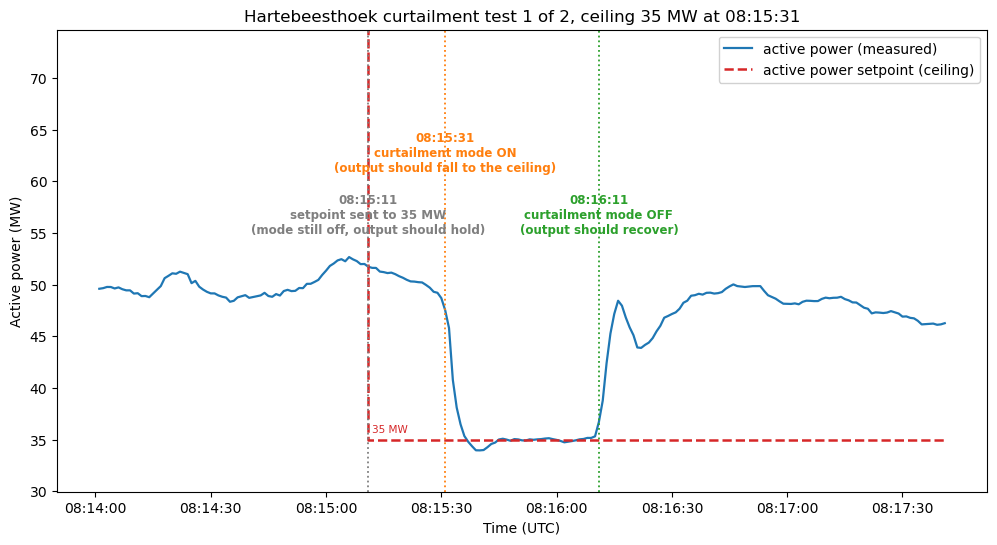


Curtailment window 2 of 2  ceiling 25 MW  figure hartebeesthoek_curtailment_084859.png
  1. Check 1: the 25 MW setpoint was sent at 08:48:43 while the mode was still off and the output kept running, so the command was received but inert.
  2. Check 2 pass: after mode ON the output settled near 25 MW, at or below the 25 MW ceiling, so the plant was curtailed to the ceiling.
  3. Check 3 pass: after mode OFF at 08:49:45 the output recovered to about 45 MW, back near its earlier 49 MW, so it returned to full output.


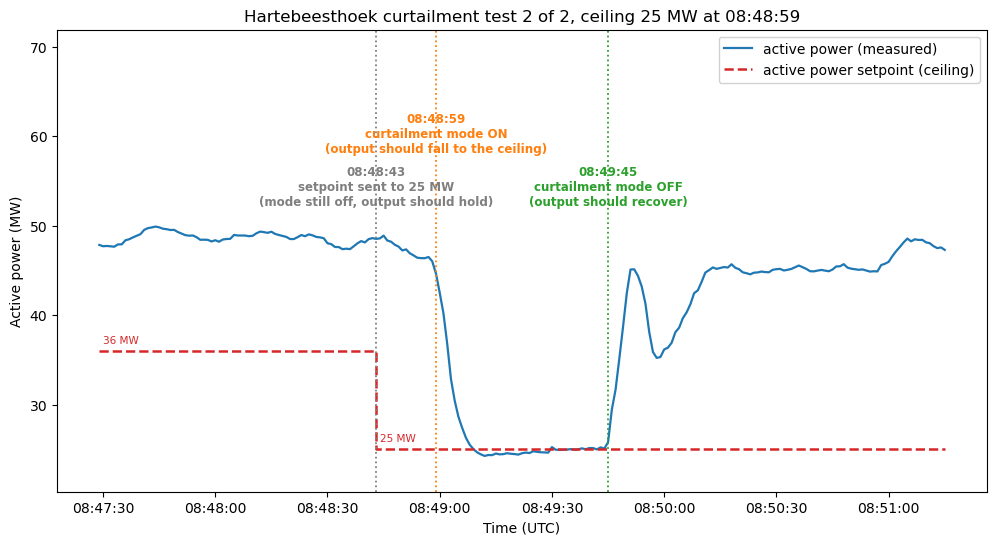

In [4]:
# =============================================================================
# CURTAILMENT TEST  (Absolute Production Constraint)
#
# What the plant must do, straight from the acceptance procedure:
#   CHECK 1  Ceiling setpoint sent while the mode is still OFF -> output should NOT
#            move yet (the command is received but inert).
#   CHECK 2  Curtailment mode ON  -> output should pull down to sit AT OR BELOW the
#            commanded ceiling.
#   CHECK 3  Curtailment mode OFF -> output should return to its earlier level.
#
# A "window" is one occurrence of the test. We find every standalone occurrence
# (curtailment mode on while the power-gradient limiter is off) and draw one graph
# and one set of findings per window. Every value is read from the data.
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. The channels this test needs, found by role (never by a fixed column name).
power_col   = resolve("poc_p", required=True)    # measured active power
setpoint_col = resolve("sp_p", required=True)    # active power setpoint (the ceiling)
curtail_col = resolve("ap_mode", required=True)  # curtailment mode on/off flag
gradient_col = resolve("pg_mode")                # power-gradient flag (used to exclude its windows)

# 2. Find every standalone curtailment window in scope (whole record unless limited).
cfg = EVENT_WINDOWS.get("curtailment")
scope = df.loc[cfg[0]:cfg[1]] if (cfg and all(cfg)) else df
windows = []
for start, end in on_segments(scope[curtail_col]):
    gradient_also_on = scope[gradient_col].astype(bool).loc[start:end].mean() if gradient_col else 0.0
    if gradient_also_on < 0.5:                    # skip windows that belong to the gradient test
        windows.append((start, end))

def plot_curtailment(mode_on, window_end, n, total):
    win      = window_around(mode_on, window_end)   # padded slice around this window
    curtail  = win[curtail_col].astype(bool)
    power    = win[power_col]                        # measured active power
    setpoint = win[setpoint_col]

    # --- Find the three procedure moments in the data ------------------------
    later_off = curtail.loc[mode_on:].index[~curtail.loc[mode_on:]]
    mode_off  = later_off[0] if len(later_off) else None     # when the mode goes off again
    sp_changes = setpoint.ne(setpoint.shift())
    sp_changes.iloc[0] = False                               # first sample is the window edge, not a change
    sent_steps = setpoint.index[sp_changes & (setpoint.index <= mode_on)]
    sp_sent   = sent_steps[-1] if len(sent_steps) else None  # the setpoint that set the ceiling
    ceiling   = setpoint.loc[mode_on]
    sent_with_mode = sp_sent is not None and abs(mode_on - sp_sent) <= pd.Timedelta(seconds=5)

    # --- The acceptance checks, computed plainly from the measured data ------
    held_output  = float(power[curtail].median())            # output while curtailment is on
    CHECK2_curtailed = held_output <= ceiling + max(1.0, 0.05 * abs(ceiling))   # at or below the ceiling?

    before_level = float(power[power.index < mode_on].median()) if (power.index < mode_on).any() else None
    after_series = power[power.index > mode_off] if mode_off is not None else power.iloc[0:0]
    after_level  = float(after_series.median()) if len(after_series) else None
    CHECK3_returned = (before_level is not None and after_level is not None
                       and after_level >= before_level - max(2.0, 0.1 * abs(before_level)))  # back to earlier level?

    # --- Draw the graph ------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(power.index, power, color="#1f77b4", lw=1.6, label="active power (measured)")
    ax.plot(setpoint.index, setpoint, color="#d62728", lw=1.8, ls="--", drawstyle="steps-post",
            label="active power setpoint (ceiling)")
    # value label on each setpoint level that is within view
    for ts, val in setpoint[setpoint.ne(setpoint.shift())].items():
        if power.min() - 5 <= val <= power.max() + 5:
            ax.annotate(f"{val:.0f} MW", xy=(ts, val), xytext=(3, 4), textcoords="offset points",
                        ha="left", va="bottom", fontsize=7.5, color="#d62728",
                        bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.6))

    # mark each moment with its time and what should happen there
    events = []
    if sent_with_mode:
        events.append((mode_on, "#ff7f0e", f"{mode_on:%H:%M:%S}\nsetpoint {ceiling:.0f} MW sent and mode ON together"))
    else:
        if sp_sent is not None:
            events.append((sp_sent, "#7f7f7f", f"{sp_sent:%H:%M:%S}\nsetpoint sent to {ceiling:.0f} MW\n(mode still off, output should hold)"))
        events.append((mode_on, "#ff7f0e", f"{mode_on:%H:%M:%S}\ncurtailment mode ON\n(output should fall to the ceiling)"))
    if mode_off is not None:
        events.append((mode_off, "#2ca02c", f"{mode_off:%H:%M:%S}\ncurtailment mode OFF\n(output should recover)"))
    mark_events(ax, events, power.max(), gap=6, fontsize=8.5)

    ax.set_ylim(power.min() - 4, power.max() + 22)
    ax.set_xlabel(f"Time ({TIME_ZONE_LABEL})")
    ax.set_ylabel("Active power (MW)")
    ax.set_title(f"{SITE_NAME} curtailment test {n} of {total}, ceiling {ceiling:.0f} MW at {mode_on:%H:%M:%S}")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.legend(loc="upper right", framealpha=0.9)
    out_path = OUTPUT_DIR / f"{SITE_SLUG}_curtailment_{mode_on:%H%M%S}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")

    # --- Findings, written straight from the checks above --------------------
    story = []
    if sent_with_mode:                                                       # CHECK 1
        story.append(f"The {ceiling:.0f} MW setpoint and the mode were switched on together at "
                     f"{mode_on:%H:%M:%S}, so there is no separate sent-but-inert phase here.")
    elif sp_sent is not None:
        story.append(f"Check 1: the {ceiling:.0f} MW setpoint was sent at {sp_sent:%H:%M:%S} while the mode "
                     f"was still off and the output kept running, so the command was received but inert.")
    else:
        story.append("The setpoint was already at its ceiling before this window, so the moment it was sent "
                     "is not captured here.")
    if CHECK2_curtailed:                                                     # CHECK 2
        story.append(f"Check 2 pass: after mode ON the output settled near {held_output:.0f} MW, at or below "
                     f"the {ceiling:.0f} MW ceiling, so the plant was curtailed to the ceiling.")
    else:
        story.append(f"Check 2 fail: after mode ON the output stayed near {held_output:.0f} MW, above the "
                     f"{ceiling:.0f} MW ceiling, so it was not curtailed to the ceiling.")
    if mode_off is None:                                                     # CHECK 3
        story.append("Curtailment mode is still on at the end of this window, so the return to full output "
                     "is not captured here.")
    elif after_level is None:
        story.append(f"Mode OFF at {mode_off:%H:%M:%S} sits at the window edge, so recovery is not captured here.")
    elif CHECK3_returned:
        story.append(f"Check 3 pass: after mode OFF at {mode_off:%H:%M:%S} the output recovered to about "
                     f"{after_level:.0f} MW, back near its earlier {before_level:.0f} MW, so it returned to full output.")
    else:
        story.append(f"Check 3 fail: after mode OFF at {mode_off:%H:%M:%S} the output recovered only to about "
                     f"{after_level:.0f} MW, below its earlier {before_level:.0f} MW, so it did not fully return.")

    print(f"\nCurtailment window {n} of {total}  ceiling {ceiling:.0f} MW  figure {out_path.name}")
    for k, line in enumerate(story, start=1):
        print(f"  {k}. {line}")
    plt.show()

# 3. One graph and one set of findings per window.
print(f"Standalone curtailment windows found: {len(windows)}")
if not windows:
    print("Curtailment mode is never on without power gradient here, so there is nothing to plot.")
for n, (start, end) in enumerate(windows, start=1):
    plot_curtailment(start, end, n, len(windows))

### What the curtailment plots show

Each standalone curtailment window tells the same three-step story, and the notebook draws one plot per window so they can be compared at a glance. Before the constraint bites, the plant runs at its operating level and the ceiling setpoint is sent while the mode is still off: the output does not move, which is the first check, the command received but inert [1]. When the mode is switched on the output falls within seconds to sit on the ceiling and holds there, respecting it as a hard maximum rather than a target to climb to. When the mode is switched off the output climbs back toward its earlier level. The printed findings under each plot carry that window's exact times, its ceiling and the recovered level, and say plainly if any phase was not captured in the data.

## Power gradient constraint test

The power gradient constraint limits how fast the plant may change its output. Instead of jumping straight to a new setpoint, the plant must move towards it at a commanded rate, measured in megawatts per minute (MW/min), with a separate limit for ramping up and ramping down. The procedure [1] sets a down rate, switches power gradient mode on, commands a lower setpoint and checks the plant descends at that rate, then sets an up rate, commands a higher setpoint and checks the plant climbs at that rate.

The cell below finds every power gradient window in the record and draws one graph per window. While the mode is engaged it measures the slope the plant follows for each setpoint change by least-squares and compares it against the commanded limit for that direction. The measured ramp is drawn as a guide line, the curtailment mode that actually drives each move is marked with its on and off times along the bottom, and the findings give the observed rate beside the commanded one, anchored to the interval it was measured over.

Power gradient windows found: 2

Power gradient window 1 of 2  figure hartebeesthoek_power_gradient_081911.png
  1. Power gradient mode was switched on at 08:19:11, so the plant should move between setpoints at the commanded rate rather than as fast as it can.
  2. At 08:19:35 the setpoint moved down to 26 MW, and from 08:20:03 to 08:20:51 the plant ramped at about 20 MW/min, close to the limit of 20 MW/min.
  3. At 08:22:06 the setpoint moved up to 36 MW, and from 08:22:11 to 08:22:51 the plant ramped at about 10 MW/min, close to the limit of 10 MW/min.
  4. Power gradient mode was released at 08:23:27.


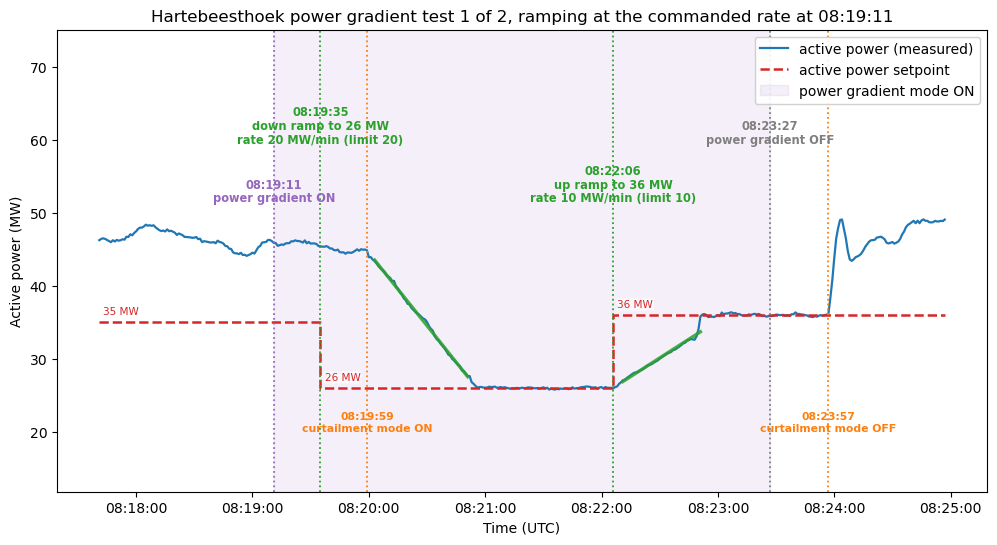


Power gradient window 2 of 2  figure hartebeesthoek_power_gradient_085141.png
  1. Power gradient mode was switched on at 08:51:41, so the plant should move between setpoints at the commanded rate rather than as fast as it can.
  2. At 08:52:15 the setpoint moved down to 39 MW, and from 08:52:29 to 08:53:21 the plant ramped at about 11 MW/min, close to the limit of 10 MW/min.
  3. At 08:54:47 the setpoint moved up to 44 MW, and from 08:54:52 to 08:55:39 the plant ramped at about 6 MW/min, close to the limit of 5 MW/min.
  4. Power gradient mode was released at 08:57:24.


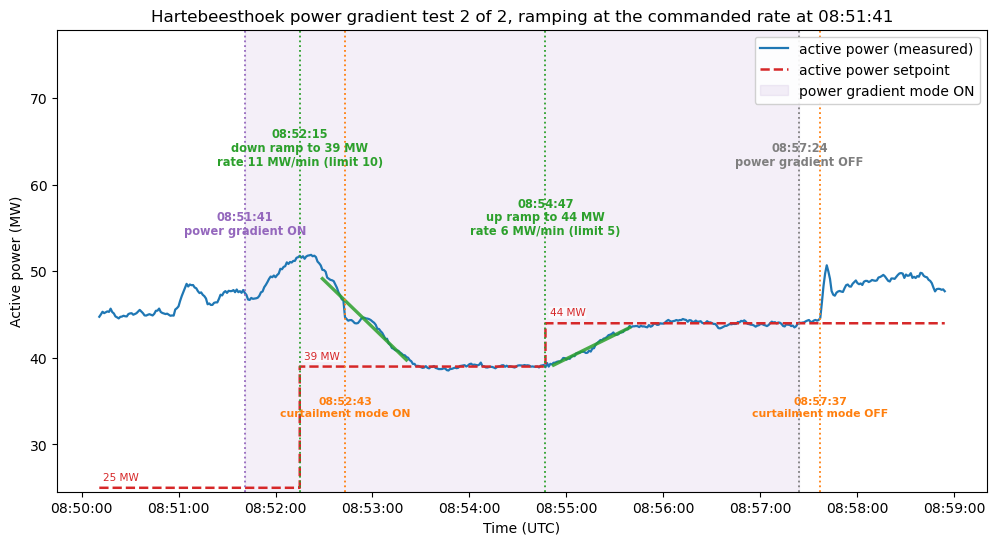

In [5]:
# =============================================================================
# POWER GRADIENT TEST  (Ramp Rate Constraint)
#
# What the plant must do, straight from the acceptance procedure:
#   With power gradient mode ON, when the active power setpoint changes the plant must
#   move to the new setpoint NO FASTER than the commanded ramp rate (MW/min). There is
#   a separate limit for ramping up and for ramping down.
#   CHECK  for each setpoint change: measured ramp rate vs the commanded limit
#          (reported as close to / faster than / slower than the limit).
#
# A "window" is one occurrence (one power-gradient-on period); one graph each. The
# curtailment mode is what physically drives the plant to each setpoint, so its on and
# off times are marked along the bottom for context.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. The channels this test needs, found by role.
power_col    = resolve("poc_p", required=True)    # measured active power
setpoint_col = resolve("sp_p", required=True)     # active power setpoint
gradient_col = resolve("pg_mode", required=True)  # power gradient mode on/off flag
curtail_col  = resolve("ap_mode")                 # curtailment flag (drives the moves)
up_limit_col   = resolve("ramp_up")               # commanded up ramp limit (MW/min)
down_limit_col = resolve("ramp_down")             # commanded down ramp limit (MW/min)

# 2. Find every power gradient window in scope (whole record unless limited).
cfg = EVENT_WINDOWS.get("power_gradient")
scope = df.loc[cfg[0]:cfg[1]] if (cfg and all(cfg)) else df
windows = on_segments(scope[gradient_col])


def measure_ramp(power_segment, start_value, target_value):
    """Measure how fast the plant actually moved, in MW per minute.

    The rate is the slope of a straight line fitted over the middle of the move, from
    10 percent risen to 90 percent risen. Using the middle skips the dead time before
    the move starts and the flattening as it arrives, so the number is the true ramp
    slope. Returns a small labelled result, or None if the move is too small to be a ramp.
    """
    total_move = target_value - start_value
    if abs(total_move) < 0.5:
        return None

    # The 10 percent and 90 percent points of the move.
    ten_percent_point = start_value + 0.1 * total_move
    ninety_percent_point = start_value + 0.9 * total_move

    # Find when the measured power first passes each point. Moving up and moving down
    # are handled separately because the comparison flips direction.
    if total_move > 0:
        passed_ten = power_segment.index[power_segment >= ten_percent_point]
        passed_ninety = power_segment.index[power_segment >= ninety_percent_point]
    else:
        passed_ten = power_segment.index[power_segment <= ten_percent_point]
        passed_ninety = power_segment.index[power_segment <= ninety_percent_point]

    # The ramp starts when it first passes 10 percent.
    if len(passed_ten) > 0:
        ramp_start = passed_ten[0]
    else:
        ramp_start = power_segment.index[0]

    # The ramp ends when it first passes 90 percent after that.
    passed_ninety = passed_ninety[passed_ninety > ramp_start]
    if len(passed_ninety) > 0:
        ramp_end = passed_ninety[0]
    else:
        ramp_end = power_segment.index[-1]

    # Fit a straight line to the power over that interval; its slope is the ramp rate.
    ramp = power_segment.loc[ramp_start:ramp_end]
    if len(ramp) < 2:
        return None
    minutes = (ramp.index - ramp.index[0]).total_seconds().to_numpy() / 60.0
    slope, intercept = np.polyfit(minutes, ramp.to_numpy(), 1)

    return {
        "rate": float(slope),                                # MW per minute
        "t_start": ramp_start,
        "p_start": float(intercept + slope * minutes[0]),    # fitted line, start point
        "t_end": ramp_end,
        "p_end": float(intercept + slope * minutes[-1]),     # fitted line, end point
    }


def find_ramps(win, gradient_on, active_until):
    """One entry per setpoint change while the mode is engaged, with its measured rate."""
    power = win[power_col]
    setpoint = win[setpoint_col]

    setpoint_changes = setpoint.ne(setpoint.shift())
    setpoint_changes.iloc[0] = False                         # first sample is the window edge
    step_times = setpoint.index[setpoint_changes]
    step_times = step_times[(step_times >= gradient_on) & (step_times <= active_until)]

    ramps = []
    for i, step_time in enumerate(step_times):
        target = setpoint.loc[step_time]
        start_value = power.loc[step_time]

        # Look at the power from this step until the next step (or the mode going off).
        if i + 1 < len(step_times):
            next_step = step_times[i + 1]
        else:
            next_step = active_until
        measured = measure_ramp(power.loc[step_time:next_step], start_value, target)
        if measured is None:
            continue

        # Which way did it move, and which commanded limit applies?
        if target < start_value:
            direction = "down"
            limit_col = down_limit_col
        else:
            direction = "up"
            limit_col = up_limit_col
        limit = win[limit_col].loc[step_time] if limit_col else None

        ramp = dict(measured)                                # copy the measured result
        ramp.update(ts=step_time, target=target, direction=direction, limit=limit)
        ramps.append(ramp)
    return ramps


def plot_power_gradient(gradient_on, window_end, n, total):
    win      = window_around(gradient_on, window_end)
    gradient = win[gradient_col].astype(bool)
    power    = win[power_col]
    setpoint = win[setpoint_col]

    # When does the mode go off again?
    still_off = gradient.loc[gradient_on:].index[~gradient.loc[gradient_on:]]
    if len(still_off) > 0:
        gradient_off = still_off[0]
    else:
        gradient_off = None
    active_until = gradient_off if gradient_off is not None else win.index[-1]

    ramps = find_ramps(win, gradient_on, active_until)

    # --- Draw the graph ------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(power.index, power, color="#1f77b4", lw=1.6, label="active power (measured)")
    ax.plot(setpoint.index, setpoint, color="#d62728", lw=1.8, ls="--", drawstyle="steps-post",
            label="active power setpoint")
    ax.axvspan(gradient_on, active_until, color="#9467bd", alpha=0.10, label="power gradient mode ON")

    # the measured slope of each ramp, drawn as a guide line
    for ramp in ramps:
        ax.plot([ramp["t_start"], ramp["t_end"]], [ramp["p_start"], ramp["p_end"]],
                color="#2ca02c", lw=2.4, alpha=0.85)

    # value label on each setpoint level
    for ts, val in setpoint[setpoint.ne(setpoint.shift())].items():
        ax.annotate(f"{val:.0f} MW", xy=(ts, val), xytext=(3, 4), textcoords="offset points",
                    ha="left", va="bottom", fontsize=7.5, color="#d62728",
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.6))

    # top markers: mode on/off and each ramp; the label reads "rate X (limit Y)"
    top_events = [(gradient_on, "#9467bd", f"{gradient_on:%H:%M:%S}\npower gradient ON")]
    for ramp in ramps:
        if ramp["limit"] is not None:
            limit_txt = f"{ramp['limit']:.0f}"
        else:
            limit_txt = "n/a"
        top_events.append((ramp["ts"], "#2ca02c",
                           f"{ramp['ts']:%H:%M:%S}\n{ramp['direction']} ramp to {ramp['target']:.0f} MW\n"
                           f"rate {abs(ramp['rate']):.0f} MW/min (limit {limit_txt})"))
    if gradient_off is not None:
        top_events.append((gradient_off, "#7f7f7f", f"{gradient_off:%H:%M:%S}\npower gradient OFF"))
    mark_events(ax, top_events, power.max(), gap=8, fontsize=8.2)

    # bottom markers: curtailment mode on and off, with their times
    if curtail_col:
        for mode_start, mode_end in on_segments(win[curtail_col]):
            for ts, text in ((mode_start, "curtailment mode ON"), (mode_end, "curtailment mode OFF")):
                ax.axvline(ts, color="#ff7f0e", ls=":", lw=1.3)
                ax.annotate(f"{ts:%H:%M:%S}\n{text}", xy=(ts, power.min()), xytext=(ts, power.min() - 3),
                            ha="center", va="top", fontsize=7.8, color="#ff7f0e", fontweight="bold")

    ax.set_ylim(power.min() - 14, power.max() + 26)
    ax.set_xlabel(f"Time ({TIME_ZONE_LABEL})")
    ax.set_ylabel("Active power (MW)")
    ax.set_title(f"{SITE_NAME} power gradient test {n} of {total}, ramping at the commanded rate at {gradient_on:%H:%M:%S}")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.legend(loc="upper right", framealpha=0.9)
    out_path = OUTPUT_DIR / f"{SITE_SLUG}_power_gradient_{gradient_on:%H%M%S}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")

    # --- Findings: one line per ramp comparing measured rate to the limit ----
    story = [f"Power gradient mode was switched on at {gradient_on:%H:%M:%S}, so the plant should move "
             "between setpoints at the commanded rate rather than as fast as it can."]
    for ramp in ramps:
        rate_txt = f"{abs(ramp['rate']):.0f} MW/min"
        interval = f"from {ramp['t_start']:%H:%M:%S} to {ramp['t_end']:%H:%M:%S}"
        if ramp["limit"] is None:
            story.append(f"At {ramp['ts']:%H:%M:%S} the setpoint moved {ramp['direction']} to {ramp['target']:.0f} MW, "
                         f"and {interval} the plant ramped at about {rate_txt}; no rate limit was recorded.")
            continue
        # CHECK: how the measured rate compares to the commanded limit
        gap = abs(ramp["rate"]) - ramp["limit"]
        if abs(gap) <= 0.2 * ramp["limit"]:
            verdict = "close to the limit"
        elif gap > 0:
            verdict = "faster than the limit"
        else:
            verdict = "slower than the limit"
        story.append(f"At {ramp['ts']:%H:%M:%S} the setpoint moved {ramp['direction']} to {ramp['target']:.0f} MW, "
                     f"and {interval} the plant ramped at about {rate_txt}, {verdict} of {ramp['limit']:.0f} MW/min.")
    if not ramps:
        story.append("No setpoint change happens while power gradient is on, so the rate limit is not "
                     "exercised in this window.")
    if gradient_off is not None:
        story.append(f"Power gradient mode was released at {gradient_off:%H:%M:%S}.")
    else:
        story.append("Power gradient mode is still on at the end of this window.")

    print(f"\nPower gradient window {n} of {total}  figure {out_path.name}")
    for k, line in enumerate(story, start=1):
        print(f"  {k}. {line}")
    plt.show()


# 3. One graph and one set of findings per window.
print(f"Power gradient windows found: {len(windows)}")
if not windows:
    print("Power gradient mode is never on here, so there is nothing to plot.")
for n, (start, end) in enumerate(windows, start=1):
    plot_power_gradient(start, end, n, len(windows))

## Frequency response

The grid runs as one synchronised machine, and its **frequency** is how fast that machine turns, measured in **hertz (Hz, cycles per second)**. The South African grid is built around a nominal 50 Hz. Frequency rises when more power is generated than is being used and falls when more is used than generated, so holding it near 50 Hz means constantly balancing supply against demand across the whole **national grid (the National Integrated Power System, NIPS)**.

When the frequency climbs too high there is too much generation on the system, and generators are asked to back off. A **renewable power plant (RPP)** like this one must take part in that correction above a set frequency. The behaviour is described by two settings. The **deadband** is a band around 50 Hz inside which the plant does nothing, so the normal small wobbles are ignored. The **droop** is the steepness of the response once the deadband is passed: the South African Grid Code defines droop as the percentage frequency change needed to move the plant all the way from no-load to rated output, so a smaller droop means a sharper cut in power for the same rise in frequency. This high-frequency case, where the plant must reduce its output, is the **over-frequency** response.

Everything is judged at the **point of connection (POC)**, the single metering point where the plant joins the grid. The test is commanded and supervised by the **System Operator (SO)**, the body that runs the grid.

This section checks the same over-frequency test two ways. First against the acceptance procedure in the test record [1], which asks for the response to be switched on, the plant observed reacting to frequency deviations outside the deadband, then switched off. Second against the South African Grid Code requirements for renewable power plants [2], which set the exact curve the power reduction must follow above 50.5 Hz and the trip that must happen above 51.5 Hz. One note before the graphs: this logger has no separate frequency-mode on or off flag, unlike the other tests, so the over-frequency test is found directly from the swept control frequency that was injected to drive it.